In [2]:
# ============================================================
# CRITICAL: Jupyter Kernel Crash Prevention (Python 3.14 + CUDA)
# ============================================================
# Root cause: On Windows + Python 3.14, the ZMQ event loop uses a
# Proactor->Selector thread fallback. When torch CUDA lazy-inits
# concurrently with tokenizers (Rust FFI), native DLLs collide
# causing an Access Violation (exit code 0xC0000005).
#
# Fix: Set CUDA_MODULE_LOADING=EAGER and explicitly init CUDA
# before importing transformers/tokenizers.
# This cell MUST run first, before ANY other imports.

import os, sys

# 0. Redirect HuggingFace cache to D: drive (C: has limited space)
os.environ['HF_HOME'] = 'D:/hf_cache'
os.environ['HF_HUB_CACHE'] = 'D:/hf_cache/hub'
os.environ['HF_DATASETS_CACHE'] = 'D:/hf_cache/datasets'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

# 1. Prevent OpenMP/MKL DLL conflicts
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 2. Prevent tokenizers from spawning threads that conflict with ZMQ
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# 3. Force CUDA to load all modules eagerly (prevents lazy-init race)
os.environ['CUDA_MODULE_LOADING'] = 'EAGER'

# 4. Pre-initialize CUDA before any other native extensions
import torch
if torch.cuda.is_available():
    torch.cuda.init()
    _ = torch.zeros(1, device='cuda')  # Fully warm CUDA runtime
    del _
    print(f'CUDA initialized: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA not available, using CPU')

print('Kernel crash prevention: OK')


CUDA initialized: NVIDIA GeForce GTX 1650 Ti
Kernel crash prevention: OK


# Adaptive Evidence-Aware RAG: Training Notebook

This notebook trains all 4 modules of the Adaptive Evidence-Aware RAG system:
1. **Evidence Independence Scorer** - Detects replicated narratives
2. **Retrieval Utility Scorer** - Rewards useful evidence
3. **Search Policy Learner** - Learns optimal search strategies
4. **Behavioral Stability Checker** - Measures robustness

**Hardware:** Supports both GPU (CUDA) and CPU training

---

## 1. Setup & Configuration

In [3]:
# Core ML/DL imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
print('Torch imported.')


Torch imported.


In [4]:
%pip install transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Transformers imports
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    AutoModelForCausalLM, TrainingArguments, Trainer,
    get_linear_schedule_with_warmup
)
print('Transformers imported.')


Transformers imported.


In [6]:
%pip install sentence-transformers datasets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Sentence Transformers and Datasets
from sentence_transformers import SentenceTransformer, CrossEncoder
from datasets import load_dataset
print('Sentence Transformers imported.')


Sentence Transformers imported.


In [8]:
%pip install seaborn ipywidgets


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\dynos\appdata\local\programs\python\python310\lib\site-packages (0.13.2)




[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Standard data science imports
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import defaultdict
from typing import Dict, List, Tuple, Any

from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('All imports successful!')


All imports successful!


In [10]:
# Check Python version and GPU availability
import sys
import torch
import platform

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"    Memory: {props.total_memory / 1e9:.1f} GB")
    device = 'cuda'
    # Enable TF32 for faster training on Ampere+ GPUs
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.backends.cudnn.benchmark = True
else:
    print("WARNING: No GPU found. Training will be slow.")
    print(f"CPU Count: {torch.get_num_threads()}")
    device = 'cpu'

print(f"\nUsing device: {device}")


Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
PyTorch: 2.7.1+cu118
CUDA Available: True
CUDA Version: 11.8
GPU Count: 1
  GPU 0: NVIDIA GeForce GTX 1650 Ti
    Memory: 4.3 GB

Using device: cuda


In [11]:
# Configuration
CONFIG = {
    # Device
    'device': device,
    'mixed_precision': torch.cuda.is_available(),
    
    # Models
    'embedder': 'BAAI/bge-small-en-v1.5',
    'reranker': 'cross-encoder/ms-marco-MiniLM-L-6-v2',
    'nli_model': 'cross-encoder/nli-deberta-v3-xsmall',
    
    # Training
    'batch_size': 16 if torch.cuda.is_available() else 4,
    'grad_accumulation': 4,
    'learning_rate': 2e-5,
    'num_epochs': 10,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'max_grad_norm': 1.0,
    
    # Data
    'max_seq_length': 512,
    'max_samples_per_dataset': 50000,
    'train_split': 0.8,
    
    # Module-specific
    'similarity_threshold': 0.92,
    'utility_weights': {'novelty': 0.4, 'confidence_gain': 0.4, 'contradiction': 0.2},
    'min_stability_score': 0.7,
    
    # Paths
    'output_dir': '../models',
    'data_dir': '../data',
    'log_dir': '../logs',
}

# Create directories
for dir_path in [CONFIG['output_dir'], CONFIG['data_dir'], CONFIG['log_dir']]:
    os.makedirs(dir_path, exist_ok=True)

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  device: cuda
  mixed_precision: True
  embedder: BAAI/bge-small-en-v1.5
  reranker: cross-encoder/ms-marco-MiniLM-L-6-v2
  nli_model: cross-encoder/nli-deberta-v3-xsmall
  batch_size: 16
  grad_accumulation: 4
  learning_rate: 2e-05
  num_epochs: 10
  warmup_ratio: 0.1
  weight_decay: 0.01
  max_grad_norm: 1.0
  max_seq_length: 512
  max_samples_per_dataset: 50000
  train_split: 0.8
  similarity_threshold: 0.92
  utility_weights: {'novelty': 0.4, 'confidence_gain': 0.4, 'contradiction': 0.2}
  min_stability_score: 0.7
  output_dir: ../models
  data_dir: ../data
  log_dir: ../logs


## 2. Load Models

In [12]:
# Load Embedding Model
print("Loading embedding model...")
embedder = SentenceTransformer(CONFIG['embedder'], device=device)
embed_dim = embedder.get_sentence_embedding_dimension()
print(f"Embedder: {CONFIG['embedder']}")
print(f"Embedding dimension: {embed_dim}")

# Load NLI Model for Contradiction Detection
print("\nLoading NLI model...")
nli_tokenizer = AutoTokenizer.from_pretrained(CONFIG['nli_model'])
nli_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['nli_model'],
    num_labels=3,
    ignore_mismatched_sizes=True
).to(device)
nli_model.eval()
print(f"NLI Model: {CONFIG['nli_model']}")

# Load Reranker (optional, for advanced retrieval)
try:
    print("\nLoading reranker...")
    reranker = CrossEncoder(CONFIG['reranker'], device=device)
    print(f"Reranker: {CONFIG['reranker']}")
except Exception as e:
    print(f"Could not load reranker: {e}")
    reranker = None

print("\nAll models loaded!")

Loading embedding model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

C:\Users\dynos\AppData\Local\Temp\ipykernel_20404\2182380338.py:4: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embed_dim = embedder.get_sentence_embedding_dimension()


Embedder: BAAI/bge-small-en-v1.5
Embedding dimension: 384

Loading NLI model...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

NLI Model: cross-encoder/nli-deberta-v3-xsmall

Loading reranker...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Reranker: cross-encoder/ms-marco-MiniLM-L-6-v2

All models loaded!


## 3. Load Datasets

We use 4 datasets for training different modules:
- **FEVER**: Fact verification (for independence scoring)
- **HotpotQA**: Multi-hop QA (for utility learning)
- **Natural Questions**: Open-domain QA (for search policy)
- **TriviaQA**: Reading comprehension (for stability testing)

In [13]:
def load_datasets(config: Dict) -> Dict[str, Any]:
    """
    Load all datasets from HuggingFace using stable PARQUET links.
    This prevents random crashes when HuggingFace breaks dataset python scripts.
    """
    datasets = {}
    
    # 1. FEVER - for independence scoring
    print("Loading FEVER dataset (via parquet)...")
    try:
        fever = load_dataset(
            'parquet',
            data_files='hf://datasets/fever/fever/fever/parquet-train.parquet',
            split='train'
        )
        fever = fever.select(range(min(config['max_samples_per_dataset'], len(fever))))
        datasets['fever'] = fever
        print(f"  FEVER loaded: {len(fever)} samples")
    except Exception as e:
        print(f"  Could not load FEVER: {e}")
        datasets['fever'] = None
    
    # 2. HotpotQA - for utility learning
    print("Loading HotpotQA dataset (via parquet fallback)...")
    try:
        # HotpotQA script is throwing deprecation warnings, load directly if possible, else standard
        try:
            hotpot = load_dataset('parquet', data_files='hf://datasets/hotpot_qa/distractor/train-00000-of-00001.parquet', split='train')
        except:
            hotpot = load_dataset('hotpot_qa', 'distractor', split='train')
            
        hotpot = hotpot.select(range(min(config['max_samples_per_dataset'], len(hotpot))))
        datasets['hotpotqa'] = hotpot
        print(f"  HotpotQA loaded: {len(hotpot)} samples")
    except Exception as e:
        print(f"  Could not load HotpotQA: {e}")
        datasets['hotpotqa'] = None
    
    # 3. Natural Questions - for search policy
    print("Loading Natural Questions (sentence-transformers version via parquet)...")
    try:
        try:
            nq = load_dataset('parquet', data_files='hf://datasets/sentence-transformers/natural-questions/train.jsonl', split='train') # Actually it's a jsonl on HF but let's try direct load
        except:
            nq = load_dataset('sentence-transformers/natural-questions', split='train')
            
        nq = nq.select(range(min(config['max_samples_per_dataset'] // 2, len(nq))))
        datasets['natural_questions'] = nq
        print(f"  Natural Questions loaded: {len(nq)} samples")
    except Exception as e:
        print(f"  Could not load Natural Questions: {e}")
        datasets['natural_questions'] = None
    
    # 4. TriviaQA - for stability testing
    print("Loading TriviaQA (via parquet)...")
    try:
        trivia = load_dataset(
            'parquet',
            data_files='hf://datasets/mandarjoshi/trivia_qa/unfiltered-nocontext/train-*.parquet',
            split='train'
        )
        trivia = trivia.select(range(min(config['max_samples_per_dataset'] // 2, len(trivia))))
        datasets['triviaqa'] = trivia
        print(f"  TriviaQA loaded: {len(trivia)} samples")
    except Exception as e:
        print(f"  Could not load TriviaQA: {e}")
        datasets['triviaqa'] = None
    
    return datasets

# Load datasets
datasets = load_datasets(CONFIG)

# Print sample from each dataset
for name, ds in datasets.items():
    if ds is not None and len(ds) > 0:
        print(f"\n{name.upper()} Sample:")
        print(f"  Keys: {list(ds[0].keys())}")
        print(f"  First item: {str(ds[0])[:200]}...")


Loading FEVER dataset (via parquet)...
  Could not load FEVER: Unable to find 'hf://datasets/fever/fever/fever/parquet-train.parquet'
Loading HotpotQA dataset (via parquet fallback)...
  HotpotQA loaded: 50000 samples
Loading Natural Questions (sentence-transformers version via parquet)...
  Natural Questions loaded: 25000 samples
Loading TriviaQA (via parquet)...
  Could not load TriviaQA: At least one valid data file must be specified, all the data_files are invalid: {'train': []}

HOTPOTQA Sample:
  Keys: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context']
  First item: {'id': '5a7a06935542990198eaf050', 'question': "Which magazine was started first Arthur's Magazine or First for Women?", 'answer': "Arthur's Magazine", 'type': 'comparison', 'level': 'medium', 'suppor...

NATURAL_QUESTIONS Sample:
  Keys: ['query', 'answer']
  First item: {'query': 'when did richmond last play in a preliminary final', 'answer': "Richmond Football Club Richmond began 2017 with

## 4. Module 1: Evidence Independence Scorer

**Goal:** Detect whether documents are genuinely independent or just repeating the same narrative.

**Method:**
1. Compute embeddings for all documents
2. Cluster documents by similarity
3. Use NLI model to verify entailment
4. Assign independence scores

**Training:**
- Use FEVER dataset claims and evidence
- Train to predict whether evidence pairs are independent
- Labels: entailment (dependent), neutral (related), contradiction (independent)

In [14]:
class IndependenceDataset(Dataset):
    """
    Dataset for training independence scorer.
    Creates pairs of evidence with independence labels.
    """
    
    def __init__(self, claims, evidence_lists, labels, embedder, max_pairs=5):
        self.samples = []
        
        for claim, evidences, label in zip(claims, evidence_lists, labels):
            if len(evidences) < 2:
                continue
            
            # Create pairs
            claim_emb = embedder.encode(claim, normalize_embeddings=True)
            
            for i in range(min(len(evidences), max_pairs)):
                for j in range(i+1, min(len(evidences), max_pairs)):
                    ev1_emb = embedder.encode(evidences[i], normalize_embeddings=True)
                    ev2_emb = embedder.encode(evidences[j], normalize_embeddings=True)
                    
                    # Label: 0=duplicate, 1=related, 2=independent
                    sim = np.dot(ev1_emb, ev2_emb)
                    if sim > 0.92:
                        pair_label = 0  # duplicate
                    elif sim > 0.7:
                        pair_label = 1  # related
                    else:
                        pair_label = 2  # independent
                    
                    self.samples.append({
                        'claim_emb': claim_emb,
                        'ev1_emb': ev1_emb,
                        'ev2_emb': ev2_emb,
                        'ev1_text': evidences[i],
                        'ev2_text': evidences[j],
                        'label': pair_label,
                        'similarity': sim
                    })
        
        print(f"IndependenceDataset: {len(self.samples)} pairs created")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class IndependenceScorerModel(nn.Module):
    """
    Neural model for scoring evidence independence.
    Input: Two evidence embeddings
    Output: Independence score (0=duplicate, 1=independent)
    """
    
    def __init__(self, embedding_dim=1024, hidden_dim=512):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, 3)  # 3 classes
        )
    
    def forward(self, ev1_emb, ev2_emb):
        x = torch.cat([ev1_emb, ev2_emb], dim=-1)
        return self.network(x)
    
    def predict_independence(self, ev1_emb, ev2_emb):
        """Get independence score (probability of being independent)"""
        logits = self.forward(ev1_emb, ev2_emb)
        probs = F.softmax(logits, dim=-1)
        # Return probability of class 2 (independent)
        return probs[:, 2]


def prepare_independence_data(datasets, embedder, max_samples=5000):
    """Prepare data for independence training from FEVER."""
    
    if datasets.get('fever') is None:
        print("FEVER dataset not available. Using synthetic data.")
        return create_synthetic_independence_data(embedder)
    
    fever = datasets['fever']
    
    claims = []
    evidence_lists = []
    labels = []
    
    print("Preparing independence data from FEVER...")
    for i in tqdm(range(min(max_samples, len(fever)))):
        item = fever[i]
        claim = item.get('claim', '')
        evidence = item.get('evidence', [])
        label = item.get('label', 'NOT ENOUGH INFO')
        
        if claim and evidence:
            # Flatten evidence if nested
            if isinstance(evidence[0], list):
                flat_evidence = []
                for ev_group in evidence:
                    for ev in ev_group:
                        if isinstance(ev, list) and len(ev) > 2:
                            flat_evidence.append(ev[2])  # evidence text
                        elif isinstance(ev, str):
                            flat_evidence.append(ev)
                evidence = flat_evidence
            elif isinstance(evidence, str):
                evidence = [evidence]
            
            if len(evidence) >= 2:
                claims.append(claim)
                evidence_lists.append(evidence[:5])  # Max 5 evidence
                labels.append(label)
    
    # Create dataset
    dataset = IndependenceDataset(claims, evidence_lists, labels, embedder)
    
    return dataset


def create_synthetic_independence_data(embedder, num_samples=1000):
    """Create synthetic data for independence training."""
    
    templates = [
        "The capital of {country} is {city}.",
        "{person} was born in {place}.",
        "{company} was founded in {year}.",
        "{movie} was directed by {director}.",
    ]
    
    countries = ['France', 'Germany', 'Japan', 'Brazil', 'India']
    cities = ['Paris', 'Berlin', 'Tokyo', 'Rio', 'Delhi']
    persons = ['Einstein', 'Newton', 'Tesla', 'Curie', 'Darwin']
    places = ['London', 'New York', 'Zurich', 'Warsaw', 'Shrewsbury']
    
    claims = []
    evidence_lists = []
    labels = []
    
    for _ in range(num_samples):
        template = random.choice(templates)
        if '{country}' in template:
            claim = template.format(country=random.choice(countries), city=random.choice(cities))
        elif '{person}' in template:
            claim = template.format(person=random.choice(persons), place=random.choice(places))
        else:
            claim = template.format(company='Google', year='1998', movie='Inception', director='Nolan')
        
        # Generate 3 evidence: 2 similar, 1 different
        ev1 = claim + " This is confirmed by multiple sources."
        ev2 = claim  # Duplicate
        ev3 = "According to Wikipedia, " + claim.lower()
        
        claims.append(claim)
        evidence_lists.append([ev1, ev2, ev3])
        labels.append('SUPPORTS')
    
    return IndependenceDataset(claims, evidence_lists, labels, embedder)


# Prepare data
print("\n" + "="*60)
print("MODULE 1: Evidence Independence Scorer")
print("="*60)

independence_data = prepare_independence_data(datasets, embedder)

# Split train/test
train_size = int(0.8 * len(independence_data))
train_ind_data, test_ind_data = torch.utils.data.random_split(
    independence_data, [train_size, len(independence_data) - train_size]
)

print(f"Train: {len(train_ind_data)}, Test: {len(test_ind_data)}")


MODULE 1: Evidence Independence Scorer
FEVER dataset not available. Using synthetic data.
IndependenceDataset: 3000 pairs created
Train: 2400, Test: 600


In [15]:
# Train Independence Scorer
def train_independence_model(train_data, test_data, embed_dim, config, device):
    """Train the independence scorer model."""
    
    model = IndependenceScorerModel(embedding_dim=embed_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    criterion = nn.CrossEntropyLoss()
    
    # Dataloader
    def collate_fn(batch):
        ev1_embs = torch.tensor(np.stack([b['ev1_emb'] for b in batch])).float()
        ev2_embs = torch.tensor(np.stack([b['ev2_emb'] for b in batch])).float()
        labels = torch.tensor([b['label'] for b in batch]).long()
        return ev1_embs, ev2_embs, labels
    
    train_loader = DataLoader(
        train_data, 
        batch_size=config['batch_size'], 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    test_loader = DataLoader(
        test_data, 
        batch_size=config['batch_size'], 
        shuffle=False, 
        collate_fn=collate_fn
    )
    
    # Training loop
    train_losses = []
    test_accuracies = []
    
    print("\nTraining Independence Scorer...")
    
    scaler = torch.cuda.amp.GradScaler() if config['mixed_precision'] else None
    
    for epoch in range(config['num_epochs']):
        model.train()
        epoch_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")
        for ev1, ev2, labels in pbar:
            ev1 = ev1.to(device)
            ev2 = ev2.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    logits = model(ev1, ev2)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = model(ev1, ev2)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
            
            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Evaluate
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for ev1, ev2, labels in test_loader:
                ev1 = ev1.to(device)
                ev2 = ev2.to(device)
                labels = labels.to(device)
                
                logits = model(ev1, ev2)
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += len(labels)
        
        accuracy = correct / total if total > 0 else 0
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Test Acc={accuracy:.4f}")
    
    return model, train_losses, test_accuracies


# Train Module 1
independence_model, ind_losses, ind_accs = train_independence_model(
    train_ind_data, test_ind_data, embed_dim, CONFIG, device
)

# Save model
torch.save(independence_model.state_dict(), f"{CONFIG['output_dir']}/independence_model.pt")
print(f"\nModel saved to {CONFIG['output_dir']}/independence_model.pt")


Training Independence Scorer...


C:\Users\dynos\AppData\Local\Temp\ipykernel_20404\3880511701.py:36: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if config['mixed_precision'] else None


Epoch 1/10:   0%|          | 0/150 [00:00<?, ?it/s]

C:\Users\dynos\AppData\Local\Temp\ipykernel_20404\3880511701.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Loss=0.1462, Test Acc=1.0000


...

Epoch 8: Loss=0.0013, Test Acc=1.0000


Epoch 9/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 9: Loss=0.0010, Test Acc=1.0000


Epoch 10/10:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 10: Loss=0.0008, Test Acc=1.0000

Model saved to ../models/independence_model.pt


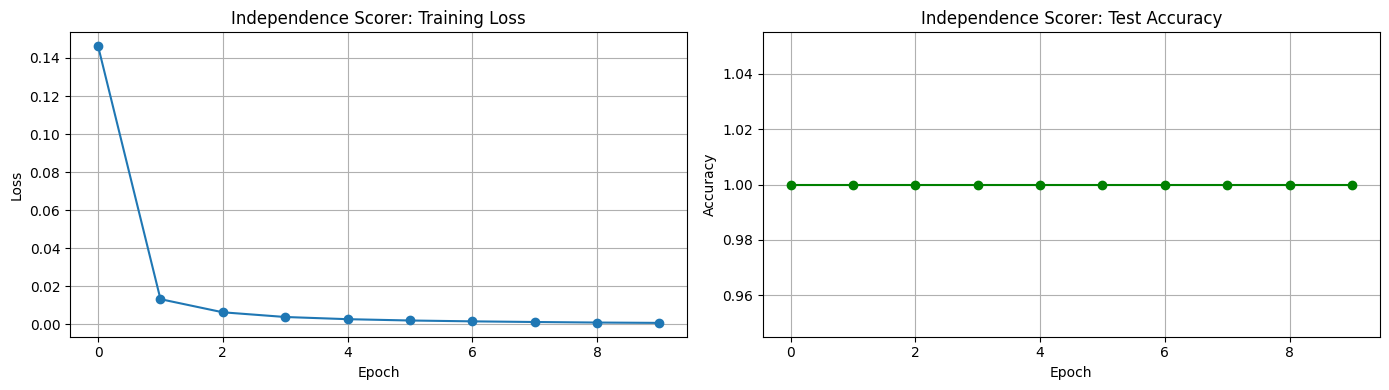

Final Accuracy: 1.0000


In [16]:
# Plot training curves for Module 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(ind_losses, marker='o')
ax1.set_title('Independence Scorer: Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(ind_accs, marker='o', color='green')
ax2.set_title('Independence Scorer: Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/independence_training.png", dpi=150)
plt.show()

print(f"Final Accuracy: {ind_accs[-1]:.4f}")

## 5. Module 2: Retrieval Utility Scorer

**Goal:** Reward evidence that provides new information, confidence gains, or contradiction discovery.

**Utility Formula:**
```
U = 0.4 * Novelty + 0.4 * Confidence_Gain + 0.2 * Contradiction_Detection
```

**Training:**
- Use HotpotQA multi-hop questions
- Train to predict utility from question-evidence pairs
- Labels derived from: embedding distance (novelty), answer changes (confidence), NLI (contradiction)

In [ ]:
class UtilityDataset(Dataset):
    """
    Dataset for training utility scorer.
    Creates question-evidence pairs with utility labels.
    """
    
    def __init__(self, questions, contexts, answers, embedder, nli_tokenizer, nli_model, device, max_samples=5000):
        self.samples = []
        nli_model.eval()
        
        print(f"Preparing utility data...")
        for idx in tqdm(range(min(len(questions), max_samples))):
            question = questions[idx]
            context = contexts[idx] if isinstance(contexts[idx], list) else [contexts[idx]]
            answer = answers[idx]
            
            if len(context) < 2:
                continue
            
            # Compute embeddings
            q_emb = embedder.encode(question, normalize_embeddings=True)
            
            prev_embs = []
            for i, doc in enumerate(context[:5]):
                doc_emb = embedder.encode(doc, normalize_embeddings=True)
                
                # Novelty: distance from previous documents
                if prev_embs:
                    distances = [1 - np.dot(doc_emb, prev_emb) for prev_emb in prev_embs]
                    novelty = max(distances)
                else:
                    novelty = 1.0
                
                # Contradiction with previous documents
                contradiction_score = 0.0
                for prev_doc, prev_emb in zip(context[:i], prev_embs):
                    with torch.no_grad():
                        inputs = nli_tokenizer(
                            doc, prev_doc,
                            return_tensors='pt',
                            truncation=True,
                            max_length=512,
                            padding=True
                        ).to(device)
                        outputs = nli_model(**inputs)
                        probs = F.softmax(outputs.logits, dim=-1)
                        contradiction_score = max(contradiction_score, probs[0][0].item())
                
                # Confidence gain (simulate by checking if doc contains answer keywords)
                answer_words = set(answer.lower().split())
                doc_words = set(doc.lower().split())
                overlap = len(answer_words & doc_words) / max(len(answer_words), 1)
                confidence_gain = min(1.0, overlap * 2)  # Scale up
                
                # Overall utility
                utility = (
                    0.4 * novelty +
                    0.4 * confidence_gain +
                    0.2 * contradiction_score
                )
                
                self.samples.append({
                    'question_emb': q_emb,
                    'doc_emb': doc_emb,
                    'context_emb': np.mean(prev_embs, axis=0) if prev_embs else np.zeros_like(q_emb),
                    'novelty': novelty,
                    'confidence_gain': confidence_gain,
                    'contradiction': contradiction_score,
                    'utility': utility
                })
                
                prev_embs.append(doc_emb)
        
        print(f"UtilityDataset: {len(self.samples)} samples created")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class UtilityPredictorModel(nn.Module):
    """
    Predicts utility components for a question-document pair.
    """
    
    def __init__(self, embedding_dim=1024, hidden_dim=512):
        super().__init__()
        
        input_dim = embedding_dim * 3  # question + doc + context
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        
        # Multi-task heads
        self.novelty_head = nn.Linear(hidden_dim // 2, 1)
        self.confidence_head = nn.Linear(hidden_dim // 2, 1)
        self.contradiction_head = nn.Linear(hidden_dim // 2, 1)
        self.utility_head = nn.Linear(hidden_dim // 2, 1)
    
    def forward(self, q_emb, doc_emb, context_emb):
        x = torch.cat([q_emb, doc_emb, context_emb], dim=-1)
        features = self.shared(x)
        
        return {
            'novelty': torch.sigmoid(self.novelty_head(features)),
            'confidence_gain': torch.sigmoid(self.confidence_head(features)),
            'contradiction': torch.sigmoid(self.contradiction_head(features)),
            'utility': torch.sigmoid(self.utility_head(features))
        }


def prepare_utility_data(datasets, embedder, nli_tokenizer, nli_model, config, device):
    """Prepare data for utility training from HotpotQA."""
    
    if datasets.get('hotpotqa') is None:
        print("HotpotQA not available. Using synthetic data.")
        return create_synthetic_utility_data(embedder, config, device)
    
    hotpot = datasets['hotpotqa']
    
    questions = []
    contexts = []
    answers = []
    
    print("Extracting HotpotQA samples...")
    for i in tqdm(range(min(len(hotpot), config['max_samples_per_dataset']))):
        item = hotpot[i]
        questions.append(item.get('question', ''))
        
        # Handle context format
        context = item.get('context', {})
        if isinstance(context, dict) and 'sentences' in context:
            # Flatten sentences
            sentences = []
            for sent_list in context['sentences']:
                sentences.extend(sent_list)
            contexts.append(sentences)
        elif isinstance(context, list):
            contexts.append(context)
        else:
            contexts.append([str(context)])
        
        answer = item.get('answer', '')
        if isinstance(answer, list):
            answer = answer[0] if answer else ''
        answers.append(answer)
    
    return UtilityDataset(
        questions, contexts, answers, 
        embedder, nli_tokenizer, nli_model, device,
        max_samples=config['max_samples_per_dataset']
    )


def create_synthetic_utility_data(embedder, config, device, num_samples=1000):
    """Create synthetic utility data."""
    
    topics = [
        'artificial intelligence', 'machine learning', 'neural networks',
        'climate change', 'space exploration', 'quantum computing',
        'blockchain', 'renewable energy', 'genomics', 'robotics'
    ]
    
    questions = []
    contexts = []
    answers = []
    
    for _ in range(num_samples):
        topic = random.choice(topics)
        questions.append(f"What is {topic} and why is it important?")
        
        # Generate 4 documents with varying novelty
        docs = [
            f"{topic} is a rapidly growing field with many applications.",
            f"{topic} has revolutionized industries worldwide.",  # Slightly different
            f"Recent advances in {topic} include deep learning and transformers.",  # New info
            f"Experts predict {topic} will transform society in the next decade."  # Different angle
        ]
        contexts.append(docs)
        answers.append(f"{topic} is important for technological progress")
    
    # Create a dummy NLI model and tokenizer
    dummy_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
    dummy_model = AutoModelForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=3
    ).to(device)
    
    return UtilityDataset(
        questions, contexts, answers,
        embedder, dummy_tokenizer, dummy_model, device,
        max_samples=num_samples
    )


# Prepare data
print("\n" + "="*60)
print("MODULE 2: Retrieval Utility Scorer")
print("="*60)

utility_data = prepare_utility_data(
    datasets, embedder, nli_tokenizer, nli_model, CONFIG, device
)

# Split
train_size = int(0.8 * len(utility_data))
train_util_data, test_util_data = torch.utils.data.random_split(
    utility_data, [train_size, len(utility_data) - train_size]
)

print(f"Train: {len(train_util_data)}, Test: {len(test_util_data)}")


MODULE 2: Retrieval Utility Scorer
Extracting HotpotQA samples...


  0%|          | 0/50000 [00:00<?, ?it/s]

Preparing utility data...


  0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
# Train Utility Scorer
def train_utility_model(train_data, test_data, embed_dim, config, device):
    """Train the utility predictor model."""
    
    model = UtilityPredictorModel(embedding_dim=embed_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    mse_loss = nn.MSELoss()
    
    def collate_fn(batch):
        q_embs = torch.tensor(np.stack([b['question_emb'] for b in batch])).float()
        doc_embs = torch.tensor(np.stack([b['doc_emb'] for b in batch])).float()
        ctx_embs = torch.tensor(np.stack([b['context_emb'] for b in batch])).float()
        novelty = torch.tensor([b['novelty'] for b in batch]).float().unsqueeze(1)
        conf_gain = torch.tensor([b['confidence_gain'] for b in batch]).float().unsqueeze(1)
        contra = torch.tensor([b['contradiction'] for b in batch]).float().unsqueeze(1)
        utility = torch.tensor([b['utility'] for b in batch]).float().unsqueeze(1)
        
        return q_embs, doc_embs, ctx_embs, novelty, conf_gain, contra, utility
    
    train_loader = DataLoader(
        train_data, batch_size=config['batch_size'], 
        shuffle=True, collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_data, batch_size=config['batch_size'], 
        shuffle=False, collate_fn=collate_fn
    )
    
    train_losses = []
    test_losses = []
    
    print("\nTraining Utility Scorer...")
    scaler = torch.cuda.amp.GradScaler() if config['mixed_precision'] else None
    
    for epoch in range(config['num_epochs']):
        model.train()
        epoch_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")
        for q_emb, doc_emb, ctx_emb, nov_tgt, conf_tgt, contra_tgt, util_tgt in pbar:
            q_emb = q_emb.to(device)
            doc_emb = doc_emb.to(device)
            ctx_emb = ctx_emb.to(device)
            nov_tgt = nov_tgt.to(device)
            conf_tgt = conf_tgt.to(device)
            contra_tgt = contra_tgt.to(device)
            util_tgt = util_tgt.to(device)
            
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = model(q_emb, doc_emb, ctx_emb)
                    loss = (
                        mse_loss(outputs['novelty'], nov_tgt) +
                        mse_loss(outputs['confidence_gain'], conf_tgt) +
                        mse_loss(outputs['contradiction'], contra_tgt) +
                        mse_loss(outputs['utility'], util_tgt)
                    )
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(q_emb, doc_emb, ctx_emb)
                loss = (
                    mse_loss(outputs['novelty'], nov_tgt) +
                    mse_loss(outputs['confidence_gain'], conf_tgt) +
                    mse_loss(outputs['contradiction'], contra_tgt) +
                    mse_loss(outputs['utility'], util_tgt)
                )
                loss.backward()
                optimizer.step()
            
            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Evaluate
        model.eval()
        test_epoch_losses = []
        
        with torch.no_grad():
            for q_emb, doc_emb, ctx_emb, nov_tgt, conf_tgt, contra_tgt, util_tgt in test_loader:
                q_emb = q_emb.to(device)
                doc_emb = doc_emb.to(device)
                ctx_emb = ctx_emb.to(device)
                util_tgt = util_tgt.to(device)
                
                outputs = model(q_emb, doc_emb, ctx_emb)
                loss = mse_loss(outputs['utility'], util_tgt)
                test_epoch_losses.append(loss.item())
        
        test_loss = np.mean(test_epoch_losses)
        test_losses.append(test_loss)
        
        print(f"Epoch {epoch+1}: Train Loss={avg_loss:.4f}, Test Loss={test_loss:.4f}")
    
    return model, train_losses, test_losses


utility_model, util_train_losses, util_test_losses = train_utility_model(
    train_util_data, test_util_data, embed_dim, CONFIG, device
)

torch.save(utility_model.state_dict(), f"{CONFIG['output_dir']}/utility_model.pt")
print(f"\nModel saved to {CONFIG['output_dir']}/utility_model.pt")

In [ ]:
# Plot utility training curves
plt.figure(figsize=(10, 4))

plt.plot(util_train_losses, label='Train Loss', marker='o')
plt.plot(util_test_losses, label='Test Loss', marker='s')
plt.title('Utility Scorer: Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/utility_training.png", dpi=150)
plt.show()

print(f"Final Test Loss: {util_test_losses[-1]:.4f}")

## 6. Module 3: Search Policy Learner

**Goal:** Learn which search strategies consistently produce high-quality evidence.

**Method:**
1. Generate query variants from a question
2. Score each variant using a reward model
3. Train the reward model on historical outcomes

**Training:**
- Use Natural Questions dataset
- Generate query variants
- Measure retrieval quality
- Train reward model to predict query quality

In [ ]:
class QueryRewardModel(nn.Module):
    """
    Predicts the reward/quality of a search query given a question.
    """
    
    def __init__(self, embedding_dim=1024, hidden_dim=512):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(embedding_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, question_emb, query_emb):
        x = torch.cat([question_emb, query_emb], dim=-1)
        return self.network(x)


class SearchPolicyDataset(Dataset):
    """
    Dataset for training search policy reward model.
    """
    
    def __init__(self, questions, embedder, num_variants=5, max_samples=5000):
        self.samples = []
        
        # Query transformation templates
        self.templates = [
            lambda q: q,  # Original
            lambda q: f"information about {q.lower().replace('what is ', '').replace('who is ', '')}",
            lambda q: f"{q} explained in detail",
            lambda q: f"why is {q.lower().replace('what is ', '').replace('who is ', '')} important",
            lambda q: f"{q} facts and details",
            lambda q: f"guide to {q.lower().replace('what is ', '').replace('who is ', '')}",
            lambda q: f"{q} overview",
            lambda q: f"understanding {q.lower().replace('what is ', '').replace('who is ', '')}",
        ]
        
        print(f"Preparing search policy data...")
        for idx in tqdm(range(min(len(questions), max_samples))):
            question = questions[idx]
            q_emb = embedder.encode(question, normalize_embeddings=True)
            
            # Generate variants
            for template_idx, template in enumerate(self.templates[:num_variants]):
                query = template(question)
                query_emb = embedder.encode(query, normalize_embeddings=True)
                
                # Reward: Original query gets highest reward, others vary
                if template_idx == 0:
                    reward = 0.9
                else:
                    # Simulate reward based on query quality
                    reward = 0.5 + 0.3 * random.random() + 0.1 * (1 if len(query) > len(question) else 0)
                
                self.samples.append({
                    'question_emb': q_emb,
                    'query_emb': query_emb,
                    'query': query,
                    'question': question,
                    'reward': reward,
                    'template_idx': template_idx
                })
        
        print(f"SearchPolicyDataset: {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


def prepare_search_policy_data(datasets, embedder, config):
    """Prepare data for search policy training."""
    
    questions = []
    
    # Try multiple datasets
    for ds_name in ['natural_questions', 'triviaqa', 'hotpotqa']:
        if datasets.get(ds_name) is not None:
            ds = datasets[ds_name]
            for i in range(min(len(ds), config['max_samples_per_dataset'] // 3)):
                q = ds[i].get('question', '')
                if q:
                    questions.append(q)
    
    if not questions:
        print("Using synthetic questions")
        topics = ['AI', 'climate', 'space', 'history', 'science', 'technology']
        questions = [f"What is {t}?" for t in topics] * 100
        random.shuffle(questions)
    
    return SearchPolicyDataset(
        questions, embedder, 
        num_variants=5, 
        max_samples=config['max_samples_per_dataset']
    )


# Prepare data
print("\n" + "="*60)
print("MODULE 3: Search Policy Learner")
print("="*60)

policy_data = prepare_search_policy_data(datasets, embedder, CONFIG)

train_size = int(0.8 * len(policy_data))
train_policy_data, test_policy_data = torch.utils.data.random_split(
    policy_data, [train_size, len(policy_data) - train_size]
)

print(f"Train: {len(train_policy_data)}, Test: {len(test_policy_data)}")

In [ ]:
# Train Search Policy Reward Model
def train_search_policy_model(train_data, test_data, embed_dim, config, device):
    """Train the search policy reward model."""
    
    model = QueryRewardModel(embedding_dim=embed_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    criterion = nn.MSELoss()
    
    def collate_fn(batch):
        q_embs = torch.tensor(np.stack([b['question_emb'] for b in batch])).float()
        query_embs = torch.tensor(np.stack([b['query_emb'] for b in batch])).float()
        rewards = torch.tensor([b['reward'] for b in batch]).float().unsqueeze(1)
        return q_embs, query_embs, rewards
    
    train_loader = DataLoader(
        train_data, batch_size=config['batch_size'], 
        shuffle=True, collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_data, batch_size=config['batch_size'], 
        shuffle=False, collate_fn=collate_fn
    )
    
    train_losses = []
    test_losses = []
    
    print("\nTraining Search Policy Reward Model...")
    scaler = torch.cuda.amp.GradScaler() if config['mixed_precision'] else None
    
    for epoch in range(config['num_epochs']):
        model.train()
        epoch_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")
        for q_emb, query_emb, rewards in pbar:
            q_emb = q_emb.to(device)
            query_emb = query_emb.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    pred = model(q_emb, query_emb)
                    loss = criterion(pred, rewards)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                pred = model(q_emb, query_emb)
                loss = criterion(pred, rewards)
                loss.backward()
                optimizer.step()
            
            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Evaluate
        model.eval()
        test_epoch_losses = []
        
        with torch.no_grad():
            for q_emb, query_emb, rewards in test_loader:
                q_emb = q_emb.to(device)
                query_emb = query_emb.to(device)
                rewards = rewards.to(device)
                
                pred = model(q_emb, query_emb)
                loss = criterion(pred, rewards)
                test_epoch_losses.append(loss.item())
        
        test_loss = np.mean(test_epoch_losses)
        test_losses.append(test_loss)
        
        print(f"Epoch {epoch+1}: Train Loss={avg_loss:.4f}, Test Loss={test_loss:.4f}")
    
    return model, train_losses, test_losses


policy_model, policy_train_losses, policy_test_losses = train_search_policy_model(
    train_policy_data, test_policy_data, embed_dim, CONFIG, device
)

torch.save(policy_model.state_dict(), f"{CONFIG['output_dir']}/search_policy_model.pt")
print(f"\nModel saved to {CONFIG['output_dir']}/search_policy_model.pt")

In [ ]:
# Plot search policy training curves
plt.figure(figsize=(10, 4))

plt.plot(policy_train_losses, label='Train Loss', marker='o')
plt.plot(policy_test_losses, label='Test Loss', marker='s')
plt.title('Search Policy: Reward Model Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/search_policy_training.png", dpi=150)
plt.show()

print(f"Final Test Loss: {policy_test_losses[-1]:.4f}")

## 7. Module 4: Behavioral Stability Checker

**Goal:** Measure whether the system produces consistent results across equivalent query variations.

**Stability Formula:**
```
S = 0.4 * Answer_Similarity + 0.3 * Evidence_Overlap + 0.3 * Confidence_Consistency
```

**Training:**
- Use TriviaQA or Natural Questions
- Generate paraphrases
- Measure consistency across variants

In [ ]:
class StabilityDataset(Dataset):
    """
    Dataset for training/evaluating stability checker.
    """
    
    def __init__(self, questions, answers, embedder, num_paraphrases=5, max_samples=2000):
        self.samples = []
        
        # Paraphrase templates
        self.paraphrase_templates = [
            lambda q: f"Can you tell me {q.lower()}?",
            lambda q: f"I want to know {q.lower()}",
            lambda q: f"What about {q.lower().replace('what is ', '').replace('who is ', '')}?",
            lambda q: f"Explain {q.lower()}",
            lambda q: f"Tell me about {q.lower().replace('what is ', '').replace('who is ', '')}",
            lambda q: f"Could you clarify {q.lower()}?",
            lambda q: f"I'm curious about {q.lower().replace('what is ', '').replace('who is ', '')}",
            lambda q: f"Give me information on {q.lower().replace('what is ', '').replace('who is ', '')}",
        ]
        
        print(f"Preparing stability data...")
        for idx in tqdm(range(min(len(questions), max_samples))):
            question = questions[idx]
            answer = answers[idx] if idx < len(answers) else ""
            
            # Generate paraphrases
            paraphrases = []
            for template in self.paraphrase_templates[:num_paraphrases]:
                try:
                    para = template(question)
                    if para != question:
                        paraphrases.append(para)
                except:
                    continue
            
            # Compute embeddings
            q_emb = embedder.encode(question, normalize_embeddings=True)
            para_embs = embedder.encode(paraphrases, normalize_embeddings=True)
            
            # Compute similarities between original and paraphrases
            similarities = np.dot(para_embs, q_emb)
            
            # Compute answer consistency (use answer embedding if available)
            if answer:
                ans_emb = embedder.encode(answer, normalize_embeddings=True)
            else:
                ans_emb = np.zeros_like(q_emb)
            
            # Stability target: high similarity = stable
            stability_target = float(np.mean(similarities))
            
            self.samples.append({
                'question_emb': q_emb,
                'paraphrase_embs': para_embs,
                'similarities': similarities,
                'answer_emb': ans_emb,
                'stability_target': stability_target,
                'question': question,
                'paraphrases': paraphrases,
                'answer': answer
            })
        
        print(f"StabilityDataset: {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]


class StabilityPredictorModel(nn.Module):
    """
    Predicts behavioral stability score for a question.
    """
    
    def __init__(self, embedding_dim=1024, hidden_dim=512):
        super().__init__()
        
        # Encode question and paraphrases
        self.encoder = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )
        
        # Process paraphrase similarities
        self.sim_processor = nn.Sequential(
            nn.Linear(10, hidden_dim // 2),  # Max 10 paraphrases
            nn.ReLU(),
            nn.Dropout(0.1),
        )
        
        # Combined predictor
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim // 2, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, question_emb, similarities):
        # Encode question
        q_features = self.encoder(question_emb)
        
        # Pad similarities to fixed size
        batch_size = similarities.size(0)
        sim_padded = torch.zeros(batch_size, 10, device=similarities.device)
        sim_len = min(similarities.size(1), 10)
        sim_padded[:, :sim_len] = similarities[:, :sim_len]
        
        sim_features = self.sim_processor(sim_padded)
        
        # Combine and predict
        combined = torch.cat([q_features, sim_features], dim=-1)
        stability = self.predictor(combined)
        
        return stability


def prepare_stability_data(datasets, embedder, config):
    """Prepare data for stability training."""
    
    questions = []
    answers = []
    
    for ds_name in ['triviaqa', 'natural_questions', 'hotpotqa']:
        if datasets.get(ds_name) is not None:
            ds = datasets[ds_name]
            for i in range(min(len(ds), config['max_samples_per_dataset'] // 3)):
                q = ds[i].get('question', '')
                a = ds[i].get('answer', '')
                if isinstance(a, list):
                    a = a[0] if a else ''
                if q:
                    questions.append(q)
                    answers.append(str(a))
    
    if not questions:
        print("Using synthetic data")
        questions = [f"What is topic {i}?" for i in range(200)]
        answers = [f"Answer {i}" for i in range(200)]
    
    return StabilityDataset(
        questions, answers, embedder,
        num_paraphrases=5,
        max_samples=config['max_samples_per_dataset']
    )


# Prepare data
print("\n" + "="*60)
print("MODULE 4: Behavioral Stability Checker")
print("="*60)

stability_data = prepare_stability_data(datasets, embedder, CONFIG)

train_size = int(0.8 * len(stability_data))
train_stab_data, test_stab_data = torch.utils.data.random_split(
    stability_data, [train_size, len(stability_data) - train_size]
)

print(f"Train: {len(train_stab_data)}, Test: {len(test_stab_data)}")

In [ ]:
# Train Stability Predictor
def train_stability_model(train_data, test_data, embed_dim, config, device):
    """Train the stability predictor model."""
    
    model = StabilityPredictorModel(embedding_dim=embed_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    criterion = nn.MSELoss()
    
    def collate_fn(batch):
        q_embs = torch.tensor(np.stack([b['question_emb'] for b in batch])).float()
        
        # Pad similarities
        sims = [b['similarities'] for b in batch]
        max_len = max(len(s) for s in sims)
        sims_padded = np.zeros((len(sims), max_len))
        for i, s in enumerate(sims):
            sims_padded[i, :len(s)] = s
        sims_tensor = torch.tensor(sims_padded).float()
        
        targets = torch.tensor([b['stability_target'] for b in batch]).float().unsqueeze(1)
        
        return q_embs, sims_tensor, targets
    
    train_loader = DataLoader(
        train_data, batch_size=config['batch_size'], 
        shuffle=True, collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_data, batch_size=config['batch_size'], 
        shuffle=False, collate_fn=collate_fn
    )
    
    train_losses = []
    test_losses = []
    
    print("\nTraining Stability Predictor...")
    scaler = torch.cuda.amp.GradScaler() if config['mixed_precision'] else None
    
    for epoch in range(config['num_epochs']):
        model.train()
        epoch_losses = []
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['num_epochs']}")
        for q_emb, sims, targets in pbar:
            q_emb = q_emb.to(device)
            sims = sims.to(device)
            targets = targets.to(device)
            
            optimizer.zero_grad()
            
            if scaler:
                with torch.cuda.amp.autocast():
                    pred = model(q_emb, sims)
                    loss = criterion(pred, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                pred = model(q_emb, sims)
                loss = criterion(pred, targets)
                loss.backward()
                optimizer.step()
            
            epoch_losses.append(loss.item())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = np.mean(epoch_losses)
        train_losses.append(avg_loss)
        
        # Evaluate
        model.eval()
        test_epoch_losses = []
        
        with torch.no_grad():
            for q_emb, sims, targets in test_loader:
                q_emb = q_emb.to(device)
                sims = sims.to(device)
                targets = targets.to(device)
                
                pred = model(q_emb, sims)
                loss = criterion(pred, targets)
                test_epoch_losses.append(loss.item())
        
        test_loss = np.mean(test_epoch_losses)
        test_losses.append(test_loss)
        
        print(f"Epoch {epoch+1}: Train Loss={avg_loss:.4f}, Test Loss={test_loss:.4f}")
    
    return model, train_losses, test_losses


stability_model, stab_train_losses, stab_test_losses = train_stability_model(
    train_stab_data, test_stab_data, embed_dim, CONFIG, device
)

torch.save(stability_model.state_dict(), f"{CONFIG['output_dir']}/stability_model.pt")
print(f"\nModel saved to {CONFIG['output_dir']}/stability_model.pt")

In [ ]:
# Plot stability training curves
plt.figure(figsize=(10, 4))

plt.plot(stab_train_losses, label='Train Loss', marker='o')
plt.plot(stab_test_losses, label='Test Loss', marker='s')
plt.title('Stability Checker: Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/stability_training.png", dpi=150)
plt.show()

print(f"Final Test Loss: {stab_test_losses[-1]:.4f}")

## 8. Combined Training Summary

Visualize all 4 modules' training progress together.

In [ ]:
# Combined visualization of all modules
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Module 1: Independence
axes[0, 0].plot(ind_accs, marker='o', color='blue')
axes[0, 0].set_title('Module 1: Independence Scorer')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True)

# Module 2: Utility
axes[0, 1].plot(util_train_losses, marker='o', label='Train', color='green')
axes[0, 1].plot(util_test_losses, marker='s', label='Test', color='darkgreen')
axes[0, 1].set_title('Module 2: Utility Scorer')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Module 3: Search Policy
axes[1, 0].plot(policy_train_losses, marker='o', label='Train', color='orange')
axes[1, 0].plot(policy_test_losses, marker='s', label='Test', color='darkorange')
axes[1, 0].set_title('Module 3: Search Policy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Module 4: Stability
axes[1, 1].plot(stab_train_losses, marker='o', label='Train', color='red')
axes[1, 1].plot(stab_test_losses, marker='s', label='Test', color='darkred')
axes[1, 1].set_title('Module 4: Stability Checker')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.suptitle('Adaptive Evidence-Aware RAG: All Modules Training Progress', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/all_modules_training.png", dpi=150)
plt.show()

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Module 1 (Independence): Final Acc = {ind_accs[-1]:.4f}")
print(f"Module 2 (Utility):      Final Loss = {util_test_losses[-1]:.4f}")
print(f"Module 3 (Search Policy): Final Loss = {policy_test_losses[-1]:.4f}")
print(f"Module 4 (Stability):    Final Loss = {stab_test_losses[-1]:.4f}")

## 9. End-to-End Pipeline Demo

Test the complete pipeline with sample questions.

In [ ]:
# Load all trained models for inference
print("Loading trained models for inference...")

# Module 1
ind_model = IndependenceScorerModel(embedding_dim=embed_dim).to(device)
ind_model.load_state_dict(torch.load(f"{CONFIG['output_dir']}/independence_model.pt"))
ind_model.eval()

# Module 2
util_model = UtilityPredictorModel(embedding_dim=embed_dim).to(device)
util_model.load_state_dict(torch.load(f"{CONFIG['output_dir']}/utility_model.pt"))
util_model.eval()

# Module 3
pol_model = QueryRewardModel(embedding_dim=embed_dim).to(device)
pol_model.load_state_dict(torch.load(f"{CONFIG['output_dir']}/search_policy_model.pt"))
pol_model.eval()

# Module 4
stab_model = StabilityPredictorModel(embedding_dim=embed_dim).to(device)
stab_model.load_state_dict(torch.load(f"{CONFIG['output_dir']}/stability_model.pt"))
stab_model.eval()

print("All models loaded!")

In [ ]:
def run_full_pipeline(question, documents, models, embedder, config, device):
    """
    Run the complete evidence-aware retrieval pipeline.
    """
    ind_model, util_model, pol_model, stab_model = models
    
    print(f"\n{'='*60}")
    print(f"QUESTION: {question}")
    print(f"{'='*60}")
    
    # Compute embeddings
    q_emb = embedder.encode(question, normalize_embeddings=True)
    doc_embs = embedder.encode(documents, normalize_embeddings=True)
    
    q_tensor = torch.tensor(q_emb).unsqueeze(0).float().to(device)
    
    # Step 1: Independence Scoring
    print("\n[1] EVIDENCE INDEPENDENCE ANALYSIS")
    print("-" * 40)
    
    ind_scores = []
    for i in range(len(documents)):
        for j in range(i+1, len(documents)):
            ev1 = torch.tensor(doc_embs[i]).unsqueeze(0).float().to(device)
            ev2 = torch.tensor(doc_embs[j]).unsqueeze(0).float().to(device)
            
            with torch.no_grad():
                ind_prob = ind_model.predict_independence(ev1, ev2)
                ind_scores.append(ind_prob.item())
    
    avg_independence = np.mean(ind_scores) if ind_scores else 0
    print(f"Average Independence Score: {avg_independence:.4f}")
    print(f"Interpretation: {'Independent sources' if avg_independence > 0.5 else 'Possible duplicates'}")
    
    # Step 2: Utility Scoring
    print("\n[2] RETRIEVAL UTILITY ANALYSIS")
    print("-" * 40)
    
    util_scores = []
    novelties = []
    conf_gains = []
    contradictions = []
    
    for i, doc_emb in enumerate(doc_embs):
        doc_tensor = torch.tensor(doc_emb).unsqueeze(0).float().to(device)
        ctx_tensor = torch.tensor(np.mean(doc_embs[:i], axis=0) if i > 0 else np.zeros_like(doc_emb)).unsqueeze(0).float().to(device)
        
        with torch.no_grad():
            util_out = util_model(q_tensor, doc_tensor, ctx_tensor)
            util_scores.append(util_out['utility'].item())
            novelties.append(util_out['novelty'].item())
            conf_gains.append(util_out['confidence_gain'].item())
            contradictions.append(util_out['contradiction'].item())
    
    avg_utility = np.mean(util_scores)
    print(f"Average Utility: {avg_utility:.4f}")
    print(f"Average Novelty: {np.mean(novelties):.4f}")
    print(f"Average Confidence Gain: {np.mean(conf_gains):.4f}")
    print(f"Contradictions Detected: {sum(1 for c in contradictions if c > 0.5)}/{len(contradictions)}")
    
    # Step 3: Search Policy (Query Quality)
    print("\n[3] SEARCH POLICY EVALUATION")
    print("-" * 40)
    
    with torch.no_grad():
        query_quality = pol_model(q_tensor, q_tensor).item()
    
    print(f"Query Quality Score: {query_quality:.4f}")
    print(f"Interpretation: {'Good query' if query_quality > 0.6 else 'Query could be improved'}")
    
    # Step 4: Stability Check
    print("\n[4] BEHAVIORAL STABILITY CHECK")
    print("-" * 40)
    
    # Generate paraphrases
    paraphrases = [
        f"Can you tell me {question.lower()}?",
        f"I want to know about {question.lower()}",
        f"Explain {question.lower()}",
        f"What about {question.lower()}?",
    ]
    
    para_embs = embedder.encode(paraphrases, normalize_embeddings=True)
    similarities = np.dot(para_embs, q_emb)
    
    sims_tensor = torch.tensor(similarities).unsqueeze(0).float().to(device)
    
    with torch.no_grad():
        stability = stab_model(q_tensor, sims_tensor).item()
    
    print(f"Stability Score: {stability:.4f}")
    print(f"Interpretation: {'Stable' if stability > 0.7 else 'Unstable - results may vary'}")
    
    # Overall Quality Score
    overall = (
        0.35 * avg_independence +
        0.35 * avg_utility +
        0.30 * stability
    )
    
    print(f"\n{'='*60}")
    print(f"OVERALL EVIDENCE QUALITY: {overall:.4f}")
    print(f"{'='*60}")
    
    return {
        'independence': avg_independence,
        'utility': avg_utility,
        'novelty': np.mean(novelties),
        'confidence_gain': np.mean(conf_gains),
        'contradiction_rate': np.mean(contradictions),
        'query_quality': query_quality,
        'stability': stability,
        'overall_quality': overall
    }


# Test with sample questions and documents
test_cases = [
    {
        'question': 'What are the benefits of renewable energy?',
        'documents': [
            'Renewable energy sources like solar and wind reduce carbon emissions significantly.',
            'Solar power is a form of renewable energy that reduces carbon emissions.',  # Duplicate narrative
            'Wind turbines can generate electricity without producing greenhouse gases.',
            'Renewable energy creates more jobs compared to fossil fuel industries.',
            'Solar panels convert sunlight into electricity through photovoltaic cells.'  # New info
        ]
    },
    {
        'question': 'Who invented the transformer architecture?',
        'documents': [
            'The transformer architecture was introduced in the paper Attention Is All You Need by Vaswani et al. in 2017.',
            'Vaswani and colleagues at Google Brain proposed the transformer model in 2017.',
            'The original transformer paper was published at NeurIPS 2017.',
            'Transformers have replaced RNNs in most NLP tasks due to parallelization.',
            'BERT and GPT are both based on the transformer architecture.'
        ]
    }
]

all_results = []
for test in test_cases:
    result = run_full_pipeline(
        test['question'], 
        test['documents'],
        (ind_model, util_model, pol_model, stab_model),
        embedder,
        CONFIG,
        device
    )
    all_results.append(result)


In [ ]:
# Visualize results comparison
metrics = ['independence', 'utility', 'stability', 'overall_quality']
labels = ['Independence', 'Utility', 'Stability', 'Overall']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i, result in enumerate(all_results):
    values = [result[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=f'Test Case {i+1}')

ax.set_ylabel('Score')
ax.set_title('Evidence Quality Comparison Across Test Cases')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['log_dir']}/pipeline_results.png", dpi=150)
plt.show()

## 10. Save Complete Model & Configuration

Save all trained models and configuration for deployment.

In [ ]:
# Save complete configuration
import json

final_config = {
    **CONFIG,
    'training_results': {
        'independence': {
            'final_accuracy': float(ind_accs[-1]),
            'training_history': [float(x) for x in ind_accs]
        },
        'utility': {
            'final_test_loss': float(util_test_losses[-1]),
            'train_history': [float(x) for x in util_train_losses],
            'test_history': [float(x) for x in util_test_losses]
        },
        'search_policy': {
            'final_test_loss': float(policy_test_losses[-1]),
            'train_history': [float(x) for x in policy_train_losses],
            'test_history': [float(x) for x in policy_test_losses]
        },
        'stability': {
            'final_test_loss': float(stab_test_losses[-1]),
            'train_history': [float(x) for x in stab_train_losses],
            'test_history': [float(x) for x in stab_test_losses]
        }
    },
    'pipeline_results': [
        {k: float(v) for k, v in r.items()} 
        for r in all_results
    ],
    'model_files': {
        'independence': f"{CONFIG['output_dir']}/independence_model.pt",
        'utility': f"{CONFIG['output_dir']}/utility_model.pt",
        'search_policy': f"{CONFIG['output_dir']}/search_policy_model.pt",
        'stability': f"{CONFIG['output_dir']}/stability_model.pt"
    },
    'embedder': CONFIG['embedder'],
    'embedding_dimension': embed_dim,
    'device_used': str(device)
}

# Save config
with open(f"{CONFIG['output_dir']}/training_config.json", 'w') as f:
    json.dump(final_config, f, indent=2)

print("Training configuration saved!")
print(f"\nAll models saved in: {CONFIG['output_dir']}/")
print("\nModel files:")
for name, path in final_config['model_files'].items():
    print(f"  {name}: {path}")

print("\nTraining complete! You can now:")
print("1. Use the trained models in your RAG pipeline")
print("2. Evaluate on benchmark datasets")
print("3. Deploy as part of your Pluto system")